# Import Libraries

In [1]:
# Import necessary libraries
import sqlite3
from sqlite3 import Error

import pandas as pd
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

import kagglehub
import csv
import os

# Import the Dataset into the Database

In [2]:
# Download the dataset
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")

# Connect to the SQLite database
conn = sqlite3.connect('image.db')

# Drop the test_images table if it exists
conn.execute(
                '''
                    DROP TABLE IF EXISTS test_images
                '''
)

# Drop the train_images table if it exists
conn.execute(
                '''
                    DROP TABLE IF EXISTS train_images
                '''
)

# Create the images table
conn.execute(
                '''
                    CREATE TABLE IF NOT EXISTS train_images(
                        image_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
                        image_name TEXT NOT NULL,
                        image_label INTEGER NOT NULL
                    )
                '''
            )

# Create the test_images table
conn.execute(
                '''
                    CREATE TABLE IF NOT EXISTS test_images(
                        image_id INTEGER PRIMARY KEY AUTOINCREMENT NOT NULL,
                        image_name TEXT NOT NULL
                    )
                '''
            )

# Import the dataset into the database and create a list of labels
training_labels = []
# Import the training images
train_path = os.path.join(path, 'train.csv')
with open(train_path, 'r') as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    for row in reader:
        image_name = row[1]
        image_label = row[2]
        training_labels.append(image_label)
        if not image_name or not image_label: # Skip if image_name or image_label is empty
            continue
        conn.execute(
            '''
                INSERT INTO train_images (image_name, image_label)
                VALUES (?, ?)
            ''',
            (image_name, image_label)
        )
        
# Import the test images
test_path = os.path.join(path, 'test.csv')
with open(test_path, 'r') as file:
    reader = csv.reader(file)
    next(reader)  # Skip the header row
    for row in reader:
        if not image_name: # Skip if image_name is empty
            continue
        image_name = row[0]
        conn.execute(
            '''
                INSERT INTO test_images (image_name)
                VALUES (?)
            ''',
            (image_name,)
        )

# Commit the changes and close the connection
conn.commit()
conn.close()

# Data Augmentation

# Create Data Pipelines

Tensor("args_0:0", shape=(), dtype=string)
Tensor("args_0:0", shape=(), dtype=string)


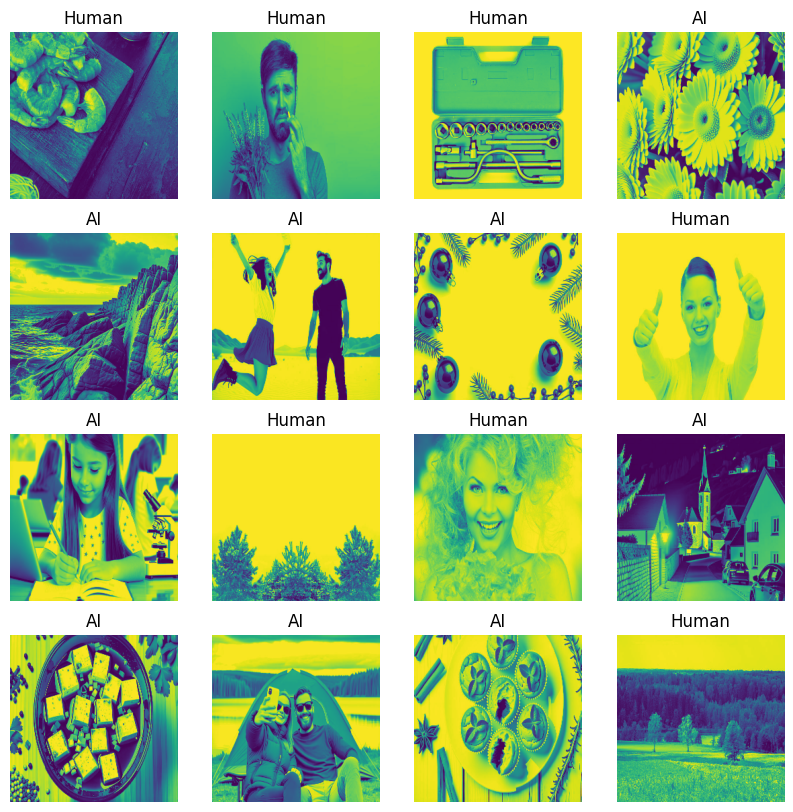

In [3]:
# Set the GPU memory growth to avoid OOM errors
#gpus = tf.config.experimental.list_physical_devices('GPU')
#for gpu in gpus:
#    tf.config.experimental.set_memory_growth(gpu, True)
#tf.keras.mixed_precision.set_global_policy('mixed_float16')
    
# Read the image data
def load_image(image_file, label=None):
    print(image_file)
    image_file = tf.squeeze(image_file)
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.rgb_to_grayscale(image)
    image = tf.image.resize(image, [250, 250])
    image = tf.cast(image, tf.float32) / 255.0
    
    return image, label

# Function to set dataset properties
def setup_dataset(dataset):
    dataset = dataset.map(load_image)
    dataset = dataset.shuffle(80000)
    dataset = dataset.batch(16).prefetch(tf.data.AUTOTUNE)
    return dataset

# Plot a batch of images
def plot_images(images, labels):
    plt.figure(figsize=(10, 10))
    # Plot 16 images in a 4x4 grid
    for i in range(16):
        # Determine the label for the image
        label = labels[i]
        if labels[i] == 1:
            label = 'AI'
        else:
            label = 'Human'
            
        # Create a subplot for each image
        ax = plt.subplot(4, 4, i + 1)
        # Load and display the image and label
        plt.imshow(images[i])
        plt.title(label)
        plt.axis('off')
    # Show the plot
    plt.show()

# Setup train dataset
train_df = pd.read_csv(train_path)
train_paths = [os.path.join(path, file) for file in train_df['file_name'].values]
train_labels = train_df['label'].values
train_images = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_images = setup_dataset(train_images)

# Setup test dataset
test_df = pd.read_csv(test_path)
test_paths = test_df['id'].values
test_images = tf.data.Dataset.from_tensor_slices((test_paths))
test_images = setup_dataset(test_images)

data_iterator = train_images.as_numpy_iterator()
imgs, lbls = data_iterator.next()

# Create a function to plot images
plot_images(imgs, lbls)

# Define Data Partitions

In [5]:
train_size = int(len(train_images) * 0.75)
val_size = len(train_images) - train_size
test_size = len(test_images)

train_data = train_images.take(train_size)
val_data = train_images.skip(train_size).take(val_size)
test_data = test_images



# Define Model

In [10]:
model = tf.keras.Sequential()

model.add(tf.keras.Input(shape=(250,250,1)))

model.add(tf.keras.layers.Conv2D(16, (3,3), 1, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Conv2D(32, (3,3), 1, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Conv2D(16, (3,3), 1, activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Compile Model

In [11]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

# Model Summary

In [12]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 248, 248, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 124, 124, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 122, 122, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 59, 59, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 29, 29, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 13456)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     3,444,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,673 (13.18 MB)

 Trainable params: 3,454,673 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [13]:
logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
history = model.fit(train_data, epochs=20, validation_data=val_data, callbacks=[tensorboard_callback])

Epoch 1/20
3747/3747 ━━━━━━━━━━━━━━━━━━━━ 1175s 247ms/step - accuracy: 0.8207 - loss: 0.4126 - val_accuracy: 0.8872 - val_loss: 0.2882
Epoch 2/20
3747/3747 ━━━━━━━━━━━━━━━━━━━━ 1570s 342ms/step - accuracy: 0.8824 - loss: 0.2983 - val_accuracy: 0.9060 - val_loss: 0.2398
Epoch 3/20
3747/3747 ━━━━━━━━━━━━━━━━━━━━ 1565s 340ms/step - accuracy: 0.9018 - loss: 0.2485 - val_accuracy: 0.9148 - val_loss: 0.2150
Epoch 4/20
3747/3747 ━━━━━━━━━━━━━━━━━━━━ 1638s 352ms/step - accuracy: 0.9218 - loss: 0.2012 - val_accuracy: 0.9481 - val_loss: 0.1556
Epoch 5/20
3747/3747 ━━━━━━━━━━━━━━━━━━━━ 1555s 336ms/step - accuracy: 0.9389 - loss: 0.1607 - val_accuracy: 0.9649 - val_loss: 0.1007
Epoch 6/20
3747/3747 ━━━━━━━━━━━━━━━━━━━━ 1559s 335ms/step - accuracy: 0.9619 - loss: 0.1069 - val_accuracy: 0.9810 - val_loss: 0.0664
Epoch 7/20
3747/3747 ━━━━━━━━━━━━━━━━━━━━ 1623s 364ms/step - accuracy: 0.9758 - loss: 0.0738 - val_accuracy: 0.9873 - val_loss: 0.0504
Epoch 8/20
3747/3747 ━━━━━━━━━━━━━━━━━━━━ 1710s 368ms/s

# Save the Model

In [18]:
model.save('AImageModelv1.keras')

# Test with Test Data

# Predictions

In [ ]:
# Add Gui

# Reporting and Visualizations